<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/5_Extracci%C3%B3n_de_Caracter%C3%ADsticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Carga desde un archivo .csv sin indice
base_leads= pd.read_csv('Analisis GAC Full7agosto 2026(Base de Leads).csv') 

In [6]:
#Verificamos información del DataFrame
base_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Fecha de Alta  210 non-null    str    
 1   Mes Lead       210 non-null    int64  
 2   AgLead         210 non-null    str    
 3   Titulo         210 non-null    str    
 4   Nombre         210 non-null    str    
 5   Telefono       0 non-null      float64
 6   Correo         0 non-null      float64
 7   Producto       196 non-null    str    
 8   Temperatura    210 non-null    str    
 9   Comentario     210 non-null    str    
 10  Asesor         210 non-null    str    
 11  Fuente         210 non-null    str    
 12  Origen         210 non-null    str    
 13                 210 non-null    str    
dtypes: float64(2), int64(1), str(11)
memory usage: 23.1 KB


In [7]:
#Imprimo los primeros 5 registro del dataframe
base_leads.head()

,Fecha de Alta,Mes Lead,AgLead,Titulo,Nombre,Telefono,Correo,Producto,Temperatura,Comentario,Asesor,Fuente,Origen,
0,11/30/2025 8:38,11,834956f716e7ddae82527bf81c29ebc8,Lead ANGE,Apolonio Torres Perez,NaN,NaN,EMZOOM,Lead Muy Interesado,Se reactiva lead para captura de ventaFinal:EM...,CESAR DE JESUS PESTAÃ‘A,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
1,11/29/2025 21:17,11,13ee2f21ed8506825e8591bf1abdab51,Lead ANGE,Javier Nieto,NaN,NaN,GS4 MAX,Lead Interes Medio,SE LE CONTACTA EN PLAZA ANGELOPOLIS Final:GS4 ...,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Finalizado
2,11/29/2025 20:48,11,fad33b39f526b4ebe04a4b7e86002d5a,Lead ANGE,Ismael Segovia Banos,NaN,NaN,GS4 MAX,Lead Muy Interesado,SE INTERESA POR GS4 Final:GS4 MAX HEV,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
3,11/29/2025 16:11,11,e495cd540b7c7dc55b516fbdc7ea8bf0,Lead ANGE,Luis Jaime Estrada,NaN,NaN,EMKOO,Lead Muy Interesado,ofrecÃ­ tambiÃ©n GS4 y emko hv Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado
4,11/29/2025 16:08,11,4d2b212032284fa42fa64a493e34c4ed,Lead ANGE,Hector Hamley,NaN,NaN,EMKOO,Lead Interes Medio,interÃ©s Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado


In [9]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = base_leads["Producto"].value_counts().reset_index()

Tabla_freq = Tabla_freq[
    Tabla_freq["Producto"] != "No envian producto valido"
]

Tabla_freq

,Producto,count
0,EMZOOM,107
1,EMKOO,76
2,GS8,7
3,GS4 MAX,2
5,GN8,1
6,AION,1


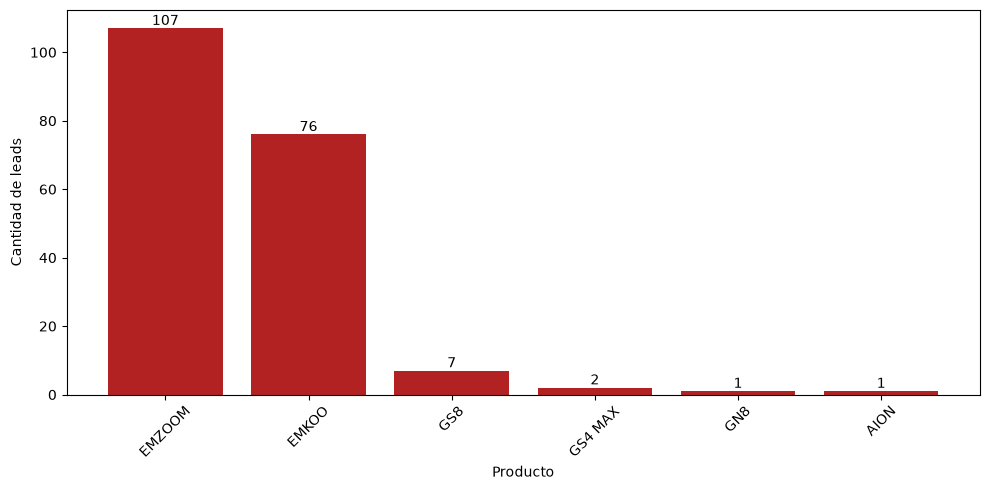

In [11]:
#Realizamos grafico de barras del dataframe filtrado
plt.figure(figsize=(10, 5))

plt.bar(
    Tabla_freq["Producto"],
    Tabla_freq["count"],
    color="firebrick"
)

plt.xlabel("Producto")
plt.ylabel("Cantidad de leads")
plt.xticks(rotation=45)

for i, cantidad in enumerate(Tabla_freq["count"]):
    plt.text(i, cantidad + 1, str(cantidad), ha="center")

plt.tight_layout()
plt.show()

In [13]:
#leemos el archivo de citas digitales
citas_digital = pd.read_csv("Analisis GAC Full7agosto 2026(Citas Digital).csv")

C:\Users\Paty\AppData\Local\Temp\ipykernel_154160\3422829551.py:2: DtypeWarning: Columns (0: BDC , 1: Fecha, 2: Nombre Cliente , 3: Telefono , 4: Estatus de Lead, 5: Potencial de compra, 6: PDM, 7: SDC, 8: Venta, 9: Asesor Asignado, 10: ¿Por que no ha visitado la agencia?, 11: ¿Por que no hay solicitud de credito?, 12: ¿Por que no hubo prueba de manejo ?, 13: ¿Por que no hubo proceso wow?, 14: ¿Por que se asigno antes de vistar piso?, 15: Unnamed: 15) have mixed types. Specify dtype option on import or set low_memory=False.
  citas_digital = pd.read_csv("Analisis GAC Full7agosto 2026(Citas Digital).csv")


In [14]:
# Convierto la variable Potencial de compra a numérica

citas_digital["Potencial_compra_num"] = pd.to_numeric(
    citas_digital["Potencial de compra"]
    .astype(str)
    .str.extract(r"(\d+)")[0],
    errors="coerce"
)

citas_digital["Potencial_compra_num"]

0          90.0
1          40.0
2          85.0
3          90.0
4          90.0
           ... 
1048570     NaN
1048571     NaN
1048572     NaN
1048573     NaN
1048574     NaN
Name: Potencial_compra_num, Length: 1048575, dtype: float64

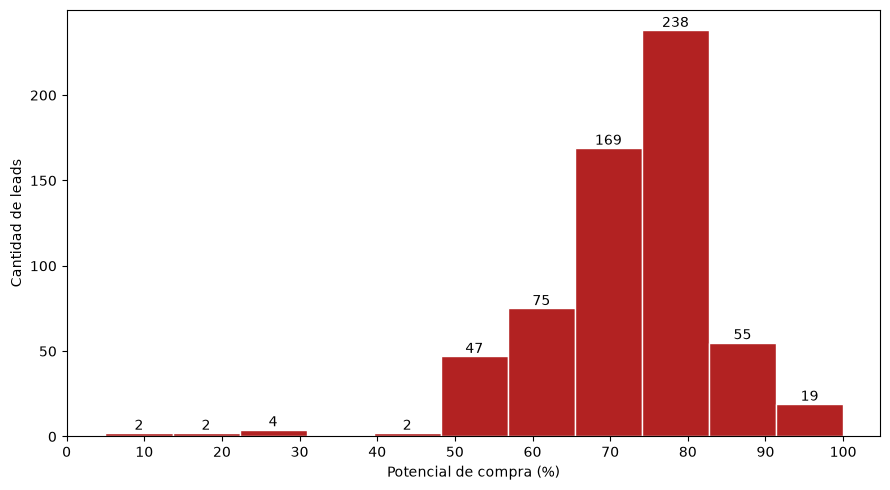

In [16]:
#creamos la gráfica
plt.figure(figsize=(9, 5))

frecuencias, intervalos, barras = plt.hist(
    citas_digital["Potencial_compra_num"].dropna(),
    bins="sturges",
    color="firebrick",
    edgecolor="white"
)

# Coloco la frecuencia encima de cada barra
for frecuencia, barra in zip(frecuencias, barras):
    if frecuencia > 0:
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            frecuencia + 2,
            str(int(frecuencia)),
            ha="center",
            fontsize=10
        )

plt.xlabel("Potencial de compra (%)")
plt.ylabel("Cantidad de leads")
plt.xticks(range(0, 101, 10))

plt.tight_layout()
plt.show()

In [19]:
# Obtengo un análisis univariado de la variable Temperatura

Tabla_temperatura = (
    base_leads["Temperatura"]
    .replace({
        "Lead Interes Medio": "Interés medio",
        "Lead Muy Interesado": "Interés alto",
        "Lead Interes Bajo": "Interés bajo"
    })
    .value_counts()
    .reset_index()
)

Tabla_temperatura

,Temperatura,count
0,Interés medio,185
1,Interés alto,21
2,Interés bajo,4


In [21]:
# Asigno un color según el nivel de interés

colores_interes = {
    "Interés alto": "green",
    "Interés medio": "gold",
    "Interés bajo": "red"
}

colores = [
    colores_interes[temperatura]
    for temperatura in Tabla_temperatura["Temperatura"]
]

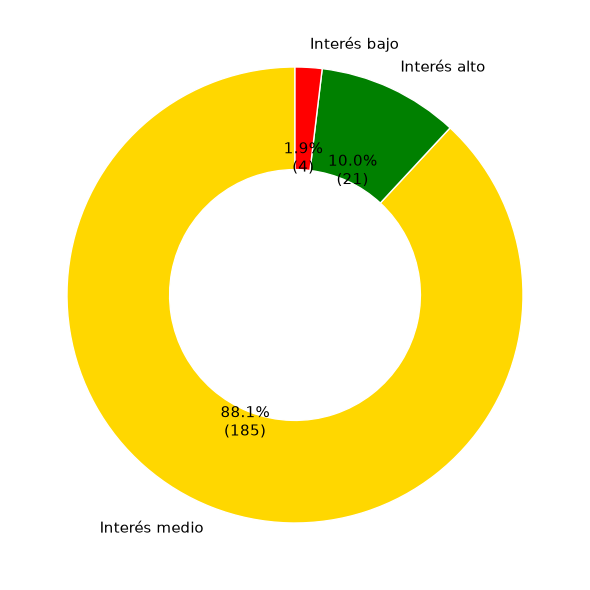

In [22]:
# Realizo una gráfica de dona de la temperatura de los leads

plt.figure(figsize=(7, 6))

total = Tabla_temperatura["count"].sum()

def mostrar_datos(porcentaje):
    cantidad = round(porcentaje * total / 100)
    return f"{porcentaje:.1f}%\n({cantidad})"

plt.pie(
    Tabla_temperatura["count"],
    labels=Tabla_temperatura["Temperatura"],
    autopct=mostrar_datos,
    startangle=90,
    colors=colores,
    wedgeprops={"width": 0.45, "edgecolor": "white"},
    textprops={"fontsize": 11}
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Leo la base TOPS TDH

tops_tdh = pd.read_csv("Analisis GAC Full7agosto 2026(TOPS TDH).csv")

In [31]:
# Conservo las primeras 20 columnas del archivo

tops_tdh = tops_tdh.iloc[:, 0:20]

# Elimino las filas completamente vacías

tops_tdh = tops_tdh.dropna(how="all").reset_index(drop=True)

tops_tdh

,INDICADORES GENERALES,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,NaN,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026 /certificación de marca,NaN,NaN,NaN,NaN,NaN,NaN
1,Mes,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio
2,Plantilla,29,29,29,30,31,33,33,34,35,36,36,36,37,40,42,44,44,44,44
3,Operando,28,24,26,27,28,29,30,32,34,34,34,32,33,37,38,40,40,42,42
4,Cumplimiento de plantilla,97%,83%,90%,90%,90%,88%,91%,94%,97%,94%,94%,89%,89%,93%,90%,91%,91%,95%,95%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,Apvs oro,4,4,4,0,0,2.4,NaN,NaN,GAC,"$5,149,975","$7,716,213","$12,882,986","$11,353,943",34,31,"$378,911","$366,256",NaN,NaN
78,Apvs plata,3,3,3,5,5,3.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,Avps bronce,7,8,9,9,8,8.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,Indefinidos (Contrato >3 Meses),29,30,37,36,35,33.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
fila_rotacion = tops_tdh[
    tops_tdh.iloc[:, 0]
    .astype(str)
    .str.contains("MENSUAL", case=False, na=False)
].index[0]

fila_rotacion

24

In [33]:
# Extraigo el objetivo ideal

objetivo_rotacion = pd.to_numeric(
    tops_tdh.iloc[fila_rotacion + 2, 1:20]
    .astype(str)
    .str.replace("%", "", regex=False),
    errors="coerce"
)

# Extraigo la rotación real

rotacion_real = pd.to_numeric(
    tops_tdh.iloc[fila_rotacion + 3, 1:20]
    .astype(str)
    .str.replace("%", "", regex=False),
    errors="coerce"
)

In [34]:
meses = [
    "Ene-25", "Feb-25", "Mar-25", "Abr-25",
    "May-25", "Jun-25", "Jul-25", "Ago-25",
    "Sep-25", "Oct-25", "Nov-25", "Dic-25",
    "Ene-26", "Feb-26", "Mar-26", "Abr-26",
    "May-26", "Jun-26", "Jul-26"
]

Tabla_rotacion = pd.DataFrame({
    "Mes": meses,
    "Rotación real (%)": rotacion_real.to_numpy(),
    "Objetivo ideal (%)": objetivo_rotacion.to_numpy()
})

Tabla_rotacion

,Mes,Rotación real (%),Objetivo ideal (%)
0,Ene-25,10.0,7.0
1,Feb-25,3.0,7.0
2,Mar-25,21.0,7.0
3,Abr-25,0.0,7.0
4,May-25,3.0,7.0
5,Jun-25,9.0,7.0
6,Jul-25,6.0,7.0
7,Ago-25,6.0,7.0
8,Sep-25,3.0,7.0
9,Oct-25,3.0,7.0


In [35]:
Tabla_rotacion = Tabla_rotacion.dropna(
    subset=["Rotación real (%)", "Objetivo ideal (%)"]
).reset_index(drop=True)

Tabla_rotacion

,Mes,Rotación real (%),Objetivo ideal (%)
0,Ene-25,10.0,7.0
1,Feb-25,3.0,7.0
2,Mar-25,21.0,7.0
3,Abr-25,0.0,7.0
4,May-25,3.0,7.0
5,Jun-25,9.0,7.0
6,Jul-25,6.0,7.0
7,Ago-25,6.0,7.0
8,Sep-25,3.0,7.0
9,Oct-25,3.0,7.0


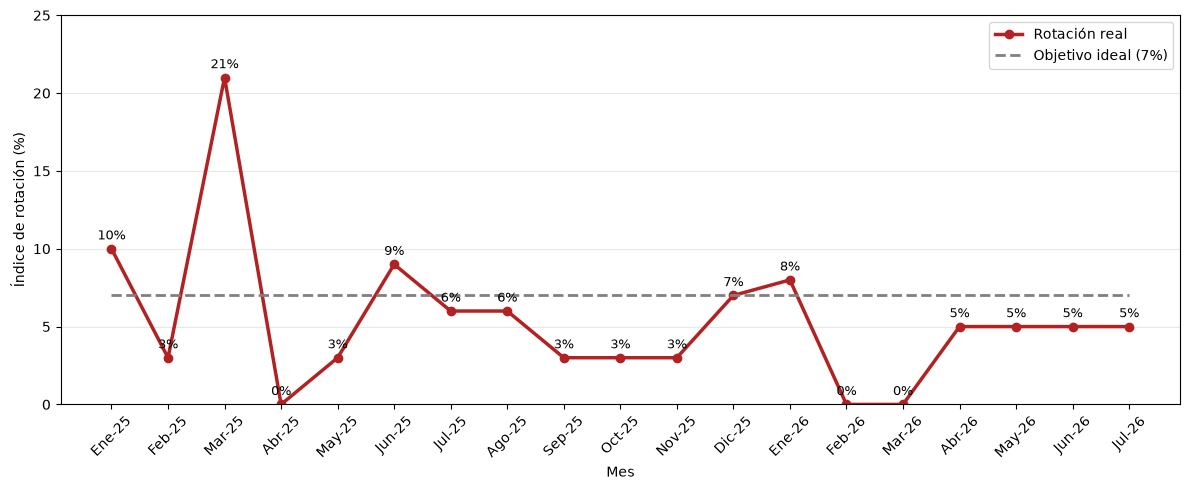

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    Tabla_rotacion["Mes"],
    Tabla_rotacion["Rotación real (%)"],
    color="firebrick",
    marker="o",
    linewidth=2.5,
    label="Rotación real"
)

plt.plot(
    Tabla_rotacion["Mes"],
    Tabla_rotacion["Objetivo ideal (%)"],
    color="gray",
    linestyle="--",
    linewidth=2,
    label="Objetivo ideal (7%)"
)

for i, valor in enumerate(Tabla_rotacion["Rotación real (%)"]):
    plt.text(
        i,
        valor + 0.6,
        f"{valor:g}%",
        ha="center",
        fontsize=9
    )

plt.xlabel("Mes")
plt.ylabel("Índice de rotación (%)")
plt.xticks(rotation=45)
plt.ylim(0, 25)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
fila_bajas = tops_tdh[
    tops_tdh.iloc[:, 0].astype(str).str.strip() == "Bajas"
].index[0]

fila_vacantes = tops_tdh[
    tops_tdh.iloc[:, 0].astype(str).str.strip() == "Vacantes"
].index[0]

fila_bajas, fila_vacantes

(5, 6)

In [38]:
bajas = pd.to_numeric(
    tops_tdh.iloc[fila_bajas, 1:20],
    errors="coerce"
)

vacantes = pd.to_numeric(
    tops_tdh.iloc[fila_vacantes, 1:20],
    errors="coerce"
)

In [39]:
Tabla_personal = pd.DataFrame({
    "Mes": meses,
    "Bajas": bajas.to_numpy(),
    "Vacantes": vacantes.to_numpy()
})

# Elimino registros nulos antes de graficar

Tabla_personal = Tabla_personal.dropna(
    subset=["Bajas", "Vacantes"]
).reset_index(drop=True)

Tabla_personal

,Mes,Bajas,Vacantes
0,Ene-25,3,1
1,Feb-25,1,5
2,Mar-25,6,3
3,Abr-25,0,3
4,May-25,1,3
5,Jun-25,3,4
6,Jul-25,2,3
7,Ago-25,2,2
8,Sep-25,1,2
9,Oct-25,1,2


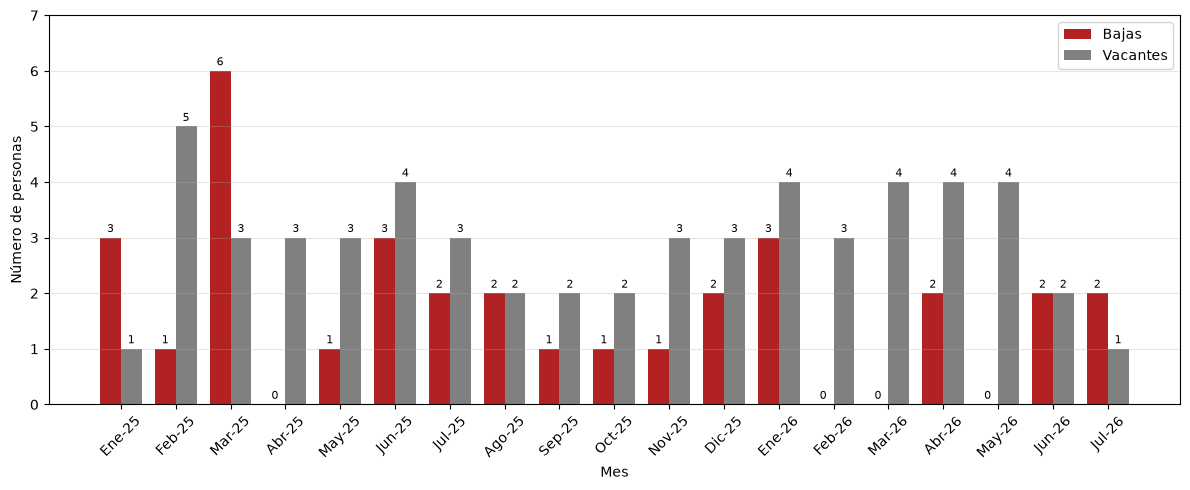

In [40]:
plt.figure(figsize=(12, 5))

x = np.arange(len(Tabla_personal))
ancho = 0.38

barras_bajas = plt.bar(
    x - ancho / 2,
    Tabla_personal["Bajas"],
    width=ancho,
    color="firebrick",
    label="Bajas"
)

barras_vacantes = plt.bar(
    x + ancho / 2,
    Tabla_personal["Vacantes"],
    width=ancho,
    color="gray",
    label="Vacantes"
)

# Coloco los valores encima de las barras

for barra in barras_bajas:
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f"{int(barra.get_height())}",
        ha="center",
        fontsize=8
    )

for barra in barras_vacantes:
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f"{int(barra.get_height())}",
        ha="center",
        fontsize=8
    )

plt.xlabel("Mes")
plt.ylabel("Número de personas")
plt.xticks(x, Tabla_personal["Mes"], rotation=45)
plt.ylim(0, 7)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
citas_digital = pd.read_csv(
    "Analisis GAC Full7agosto 2026(Citas Digital).csv")

C:\Users\Paty\AppData\Local\Temp\ipykernel_154160\754172821.py:1: DtypeWarning: Columns (0: BDC , 1: Fecha, 2: Nombre Cliente , 3: Telefono , 4: Estatus de Lead, 5: Potencial de compra, 6: PDM, 7: SDC, 8: Venta, 9: Asesor Asignado, 10: ¿Por que no ha visitado la agencia?, 11: ¿Por que no hay solicitud de credito?, 12: ¿Por que no hubo prueba de manejo ?, 13: ¿Por que no hubo proceso wow?, 14: ¿Por que se asigno antes de vistar piso?, 15: Unnamed: 15) have mixed types. Specify dtype option on import or set low_memory=False.
  citas_digital = pd.read_csv(


In [42]:
citas_digital = citas_digital.rename(
    columns={citas_digital.columns[0]: "BDC"}
)

citas_digital.columns

Index(['BDC', 'Fecha', 'Nombre Cliente ', 'Telefono ', 'Estatus de Lead',
       'Potencial de compra', 'PDM', 'SDC', 'Venta', 'Asesor Asignado',
       '¿Por que no ha visitado la agencia?',
       '¿Por que no hay solicitud de credito?',
       '¿Por que no hubo prueba de manejo ?', '¿Por que no hubo proceso wow?',
       '¿Por que se asigno antes de vistar piso?', 'Unnamed: 15'],
      dtype='str')

In [43]:
citas_digital["BDC"] = (
    citas_digital["BDC"]
    .astype(str)
    .str.strip()
    .replace({
        "ana": "Ana",
        "Igancio": "Ignacio",
        "Antonio/Saul": "Compartido"
    })
)

In [45]:
# Conservo únicamente los nombres válidos de BDC

bdc_validos = [
    "Ana",
    "Antonio",
    "Ignacio",
    "Saul",
    "Compartido"
]

citas_digital = citas_digital[
    citas_digital["BDC"].isin(bdc_validos)
].copy()

citas_digital["BDC"].value_counts()

BDC
Ana           303
Antonio       223
Ignacio        76
Saul           56
Compartido      1
Name: count, dtype: int64

In [46]:
# Obtengo un análisis univariado de la variable BDC

Tabla_bdc = (
    citas_digital["BDC"]
    .value_counts()
    .reset_index()
)

Tabla_bdc

,BDC,count
0,Ana,303
1,Antonio,223
2,Ignacio,76
3,Saul,56
4,Compartido,1


In [47]:
Tabla_bdc_grafica = Tabla_bdc.sort_values(
    by="count",
    ascending=True
)

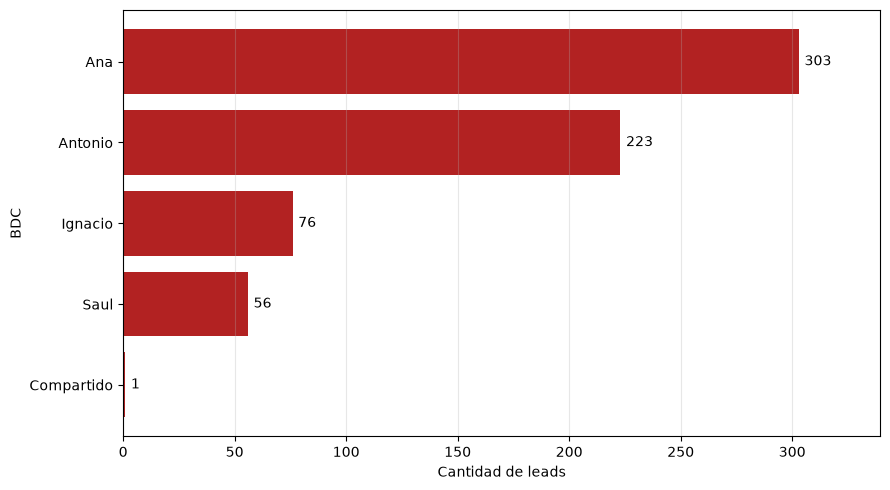

In [48]:
plt.figure(figsize=(9, 5))

barras = plt.barh(
    Tabla_bdc_grafica["BDC"],
    Tabla_bdc_grafica["count"],
    color="firebrick"
)

# Coloco las cantidades al final de cada barra

plt.bar_label(
    barras,
    padding=4,
    fontsize=10
)

plt.xlabel("Cantidad de leads")
plt.ylabel("BDC")

plt.xlim(
    0,
    Tabla_bdc_grafica["count"].max() * 1.12
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
base_leads = pd.read_csv(
    "Analisis GAC Full7agosto 2026(Base de Leads).csv")

base_leads

,Fecha de Alta,Mes Lead,AgLead,Titulo,Nombre,Telefono,Correo,Producto,Temperatura,Comentario,Asesor,Fuente,Origen,
0,11/30/2025 8:38,11,834956f716e7ddae82527bf81c29ebc8,Lead ANGE,Apolonio Torres Perez,NaN,NaN,EMZOOM,Lead Muy Interesado,Se reactiva lead para captura de ventaFinal:EM...,CESAR DE JESUS PESTAÃ‘A,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
1,11/29/2025 21:17,11,13ee2f21ed8506825e8591bf1abdab51,Lead ANGE,Javier Nieto,NaN,NaN,GS4 MAX,Lead Interes Medio,SE LE CONTACTA EN PLAZA ANGELOPOLIS Final:GS4 ...,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Finalizado
2,11/29/2025 20:48,11,fad33b39f526b4ebe04a4b7e86002d5a,Lead ANGE,Ismael Segovia Banos,NaN,NaN,GS4 MAX,Lead Muy Interesado,SE INTERESA POR GS4 Final:GS4 MAX HEV,MAURICIO ALFREDO VAZQUEZ FARFAN,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,1 Ventas
3,11/29/2025 16:11,11,e495cd540b7c7dc55b516fbdc7ea8bf0,Lead ANGE,Luis Jaime Estrada,NaN,NaN,EMKOO,Lead Muy Interesado,ofrecÃ­ tambiÃ©n GS4 y emko hv Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado
4,11/29/2025 16:08,11,4d2b212032284fa42fa64a493e34c4ed,Lead ANGE,Hector Hamley,NaN,NaN,EMKOO,Lead Interes Medio,interÃ©s Pidieron:EMKOO HEV,RICARDO SILVA HERAS,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,11/03/2025 17:27,11,6a3ea80eb04d295f086c78b21c4f3b7a,Lead ANGE,Celestino Garcia,NaN,NaN,EMZOOM,Lead Interes Medio,va a vender su i10Pidieron:EMZOOM,OMAR HERNANDEZ GARCIA,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Finalizado
206,11/03/2025 17:27,11,e3bfbfe06043bf02d562037edded5de6,Lead ANGE,Alvaro Delgadillo,NaN,NaN,EMZOOM,Lead Interes Medio,Se reactiva lead para captura de citaFinal:EMZOOM,Alan GonzÃ¡lez Belanzate,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Finalizado
207,11/03/2025 13:36,11,95bb2e63079be46c032e83459f0e9a90,Lead ANGE,Eden Castallon,NaN,NaN,EMZOOM,Lead Interes Medio,Interes EMZOOM Pidieron:EMZOOM,Alan GonzÃ¡lez Belanzate,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Finalizado
208,11/02/2025 12:44,11,801ce20ce803347f8cd9bb4239a679b2,Lead ANGE,Eduardo Cervantes,NaN,NaN,EMZOOM,Lead Interes Medio,se envÃ­a informaciÃ³n Pidieron:EMZOOM,Pedro GonzÃ¡les EspÃ­ndol,11.Origen Personalizado/Calle,PLAZA ANGELOPOLIS,Contactado


In [50]:
base_leads = base_leads.dropna(
    subset=["Nombre", "Titulo"]
).copy()

base_leads.shape

(210, 14)

In [51]:
base_leads["Tipo de lead"] = (
    base_leads["Titulo"]
    .astype(str)
    .str.strip()
    .replace({
        "Lead  ANGE": "Lead nuevo",
        "Lead  ANGE - Return": "Lead de retorno"
    })
)

base_leads["Tipo de lead"].value_counts()

Tipo de lead
Lead nuevo         196
Lead de retorno     14
Name: count, dtype: int64

In [52]:
tipos_validos = [
    "Lead nuevo",
    "Lead de retorno"
]

base_leads = base_leads[
    base_leads["Tipo de lead"].isin(tipos_validos)
].copy()

In [53]:
Tabla_tipo_lead = (
    base_leads["Tipo de lead"]
    .value_counts()
    .reset_index()
)

Tabla_tipo_lead

,Tipo de lead,count
0,Lead nuevo,196
1,Lead de retorno,14


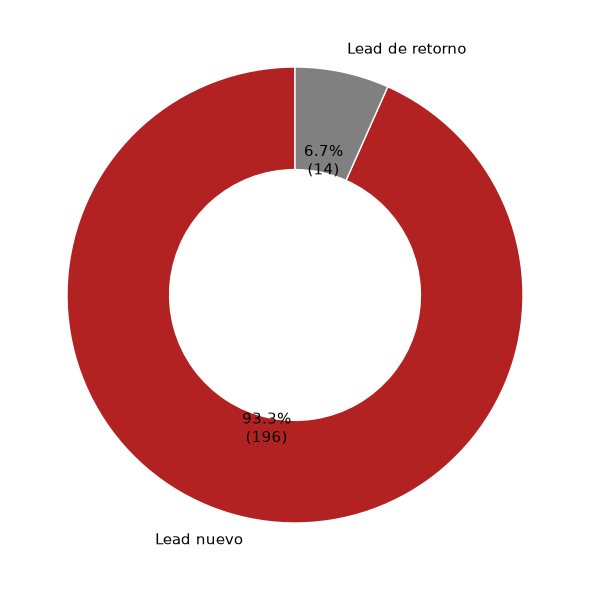

In [55]:
plt.figure(figsize=(7, 6))

total = Tabla_tipo_lead["count"].sum()

def mostrar_datos(porcentaje):
    cantidad = round(porcentaje * total / 100)
    return f"{porcentaje:.1f}%\n({cantidad})"

plt.pie(
    Tabla_tipo_lead["count"],
    labels=Tabla_tipo_lead["Tipo de lead"],
    autopct=mostrar_datos,
    startangle=90,
    colors=["firebrick", "grey"],
    wedgeprops={
        "width": 0.45,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 11
    }
)

plt.tight_layout()
plt.show()

In [56]:
ventas = pd.read_csv(
    "Analisis GAC Full7agosto 2026(Ventas).csv")

ventas

,Ventas,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 87,Unnamed: 88,Unnamed: 89,Unnamed: 90,Unnamed: 91,Unnamed: 92,Unnamed: 93,Unnamed: 94,Unnamed: 95,Unnamed: 96
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Indicador Cumplimiento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Indicador,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
# Conservo las columnas del periodo mensual

ventas = ventas.iloc[:, 0:33]

# Elimino únicamente las filas completamente vacías

ventas = ventas.dropna(how="all").reset_index(drop=True)

ventas

,Ventas,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,Indicador Cumplimiento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Indicador,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,...,Noviembre,Diciembre,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Total Interno
3,Obj Interno,NaN,15,15,15,15,15,20,23,24,...,45,50,40,38,40,40,40,40,40,938
4,Obj Margen Variable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,35,35,37,35,36,38,38,39,42,568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,SANTANDER,NaN,2,3,5,5,5,12,9,5,...,10,6,10,10,8,10,7,7,1,272
114,SCOTIABANK,NaN,,,,1,,,,,...,NaN,NaN,NaN,NaN,NaN,NaN,3,1,1,4
115,BANCO DEL BAJIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,1
116,KUNA CAPITAL SERVICE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN,1


In [58]:
fila_conversion = ventas[
    ventas.iloc[:, 0]
    .astype(str)
    .str.contains("conversion", case=False, na=False)
].index[0]

fila_conversion

9

In [59]:
conversion = pd.to_numeric(
    ventas.iloc[fila_conversion, 1:32]
    .astype(str)
    .str.replace("%", "", regex=False),
    errors="coerce"
)

conversion

Unnamed: 1       NaN
Unnamed: 2      3.08
Unnamed: 3      5.47
Unnamed: 4      2.78
Unnamed: 5      4.74
Unnamed: 6      0.97
Unnamed: 7      3.68
Unnamed: 8      3.11
Unnamed: 9      3.21
Unnamed: 10     2.80
Unnamed: 11     2.12
Unnamed: 12     3.32
Unnamed: 13     3.60
Unnamed: 14     4.27
Unnamed: 15     4.10
Unnamed: 16     3.44
Unnamed: 17     4.91
Unnamed: 18     5.76
Unnamed: 19     4.03
Unnamed: 20     4.33
Unnamed: 21     6.21
Unnamed: 22     5.76
Unnamed: 23     5.65
Unnamed: 24     4.66
Unnamed: 25     5.32
Unnamed: 26     4.11
Unnamed: 27     4.34
Unnamed: 28     5.66
Unnamed: 29     4.76
Unnamed: 30     4.91
Unnamed: 31    11.70
Name: 9, dtype: float64

In [60]:
meses_conversion = [
    "Ene-24", "Feb-24", "Mar-24", "Abr-24",
    "May-24", "Jun-24", "Jul-24", "Ago-24",
    "Sep-24", "Oct-24", "Nov-24", "Dic-24",
    
    "Ene-25", "Feb-25", "Mar-25", "Abr-25",
    "May-25", "Jun-25", "Jul-25", "Ago-25",
    "Sep-25", "Oct-25", "Nov-25", "Dic-25",
    
    "Ene-26", "Feb-26", "Mar-26", "Abr-26",
    "May-26", "Jun-26", "Jul-26"
]

In [61]:
Tabla_conversion = pd.DataFrame({
    "Mes": meses_conversion,
    "Conversión (%)": conversion.to_numpy()
})

# Enero de 2024 no tiene información, por lo que se elimina

Tabla_conversion = Tabla_conversion.dropna(
    subset=["Conversión (%)"]
).reset_index(drop=True)

Tabla_conversion

,Mes,Conversión (%)
0,Feb-24,3.08
1,Mar-24,5.47
2,Abr-24,2.78
3,May-24,4.74
4,Jun-24,0.97
5,Jul-24,3.68
6,Ago-24,3.11
7,Sep-24,3.21
8,Oct-24,2.80
9,Nov-24,2.12


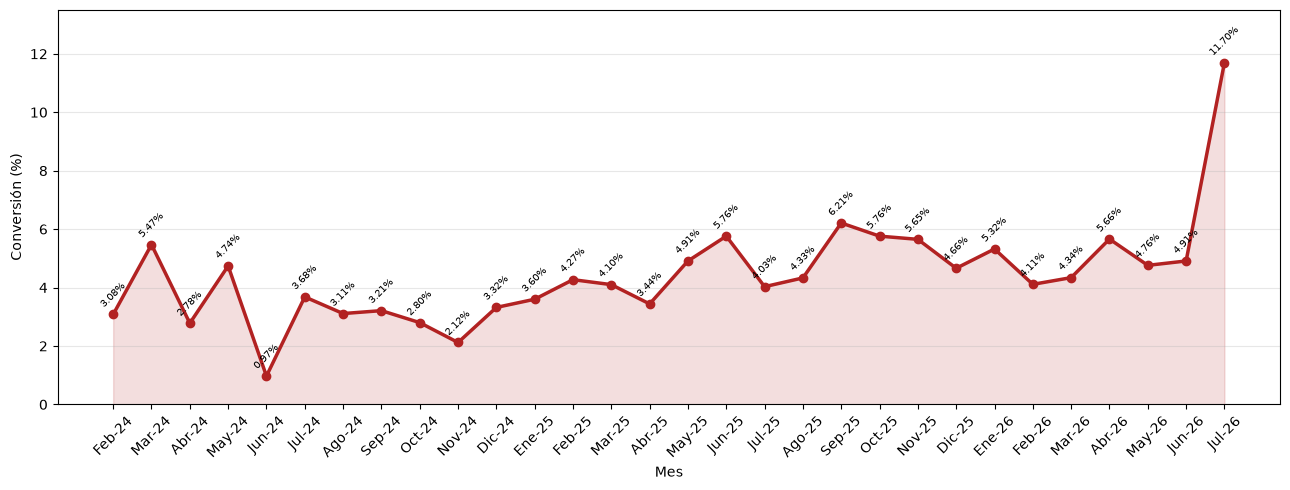

In [62]:
plt.figure(figsize=(13, 5))

plt.plot(
    Tabla_conversion["Mes"],
    Tabla_conversion["Conversión (%)"],
    color="firebrick",
    marker="o",
    linewidth=2.5
)

plt.fill_between(
    Tabla_conversion["Mes"],
    Tabla_conversion["Conversión (%)"],
    color="firebrick",
    alpha=0.15
)

# Coloco los porcentajes encima de cada punto

for i, valor in enumerate(Tabla_conversion["Conversión (%)"]):
    plt.text(
        i,
        valor + 0.25,
        f"{valor:.2f}%",
        ha="center",
        fontsize=7,
        rotation=45
    )

plt.xlabel("Mes")
plt.ylabel("Conversión (%)")
plt.xticks(rotation=45)
plt.ylim(0, 13.5)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()